# Cumulative Likelihood Over Time

This notebook plots the cumulative likelihood curve for one sequence within the NLL interval (numerically stable version: cumulative log-likelihood).

Notes:
- The curve starts at `t_nll_start`.
- At each event time, it accumulates `log p(\tau_i | H_{t_i^-})`.
- At the end time `t_end`, it additionally includes the terminal survival term `log S(\tau_{end})`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Bootstrap import path so notebook can import project modules when started from notebook dir.
cwd = Path.cwd().resolve()
for candidate in (cwd, cwd.parent):
    if (candidate / 'src').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.train.config_setup import load_and_prepare_model, load_args_from_checkpoint
from src.utils.bootstrap_ci import resolve_seed_checkpoint_paths
from src.utils.runtime_utils import resolve_project_root
from src.utils.tpp_experiments import load_tpp_catalog

# Normalize root resolution via shared utility after path bootstrap.
PROJECT_ROOT = resolve_project_root()

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'DEVICE = {DEVICE}')

PROJECT_ROOT = /root/autodl-tmp/em_eqf
DEVICE = cuda:0


## 2. Load Model Configuration Catalog

This cell reads the model-spec catalog from JSON and prints the available configuration presets for comparison.

In [2]:
from copy import deepcopy
import json
import re

NOTEBOOK_NAME = 'cumulative_likelihood_over_time'
MODEL_SPEC_CONFIG_ROOT = PROJECT_ROOT / 'notebooks' / 'config' / 'model_specs'
MODEL_SPEC_CONFIG_DIR = MODEL_SPEC_CONFIG_ROOT / NOTEBOOK_NAME
MODEL_SPEC_CONFIG_FILE = f'model_specs.{NOTEBOOK_NAME}.v1.json'
MODEL_SPEC_CONFIG_PATH = MODEL_SPEC_CONFIG_DIR / MODEL_SPEC_CONFIG_FILE

if not MODEL_SPEC_CONFIG_DIR.exists():
    raise FileNotFoundError(f'Model spec config dir not found: {MODEL_SPEC_CONFIG_DIR}')

if not MODEL_SPEC_CONFIG_PATH.exists():
    raise FileNotFoundError(f'Model spec config file not found: {MODEL_SPEC_CONFIG_PATH}')

with open(MODEL_SPEC_CONFIG_PATH, 'r', encoding='utf-8') as f:
    model_spec_catalog = json.load(f)
config_map = model_spec_catalog.get('configs', {})
if not isinstance(config_map, dict) or len(config_map) == 0:
    raise ValueError(f'Invalid config format in {MODEL_SPEC_CONFIG_PATH}: missing non-empty "configs".')

available_config_names = sorted(config_map.keys())
print('Available model spec configs:')
for cfg_name in available_config_names:
    cfg = config_map.get(cfg_name, {})
    cfg_desc = cfg.get('description', '')
    cfg_models = cfg.get('models', [])
    cfg_model_count = len(cfg_models) if isinstance(cfg_models, list) else 0
    if cfg_desc:
        print(f'  - {cfg_name}: {cfg_desc} (models={cfg_model_count})')
    else:
        print(f'  - {cfg_name} (models={cfg_model_count})')

Available model spec configs:
  - CB_HAB1a: CB_HAB1a(-0.4) full comparison: ETAS family + RECAST family + Oracle (models=8)
  - CB_HAB4: CB_HAB4 full comparison: ETAS family + RECAST family + Oracle (models=8)
  - CCL: CCL full comparison: ETAS family + RECAST family (models=2)
  - PNR_1z: PNR_1z full comparison: ETAS family + RECAST family + Oracle (models=8)
  - St1_2018: St1-2018(-0.5) full comparison: ETAS family + RECAST family + Oracle (models=8)


## 3. Select Experiment Setup and Load Models

This cell selects one preset, validates checkpoints, loads all models, chooses the evaluation split/sequence, and applies optional `t_nll_start` overrides.

In [3]:
MODEL_SPEC_CONFIG_NAME = 'St1_2018'
USE_TORCH_COMPILE = False
SPLIT = 'test'   # Options: train / val / test
SEQ_INDEX = 0
STRICT_SAME_DATASET = True

# Optional override: reset t_nll_start close to zero for broader-window comparison.
RESET_T_NLL_START_NEAR_ZERO = True
OVERRIDE_T_NLL_START_VALUE = 1e-6
OVERRIDE_T_NLL_START_EPS = 1e-6

# Optional plotting mode: plot cumulative curves relative to a baseline model.
PLOT_DELTA_TO_BASELINE = True
BASELINE_MODEL_LABEL = 'ETAS' #'ETAS'

# Optional CIG plotting mode: reset plotted CIG to 0 at split starts.
# This only changes the displayed/exported plot value; raw full-window CIG is kept.
RESET_CIG_AT_SPLIT_BOUNDARIES = True
CIG_RESET_BOUNDARY_SPLITS = ('val', 'test')

# Select cumulative component to plot and validate against model NLL.
# 'time': time-only NLL; 'total': full NLL including BG/auxiliary terms.
PLOT_COMPONENT = 'time'
if PLOT_COMPONENT not in {'time', 'total'}:
    raise ValueError("PLOT_COMPONENT must be one of {'time', 'total'}.")

# Prefix micro-batch size for cumulative prefix evaluation.
# Increase for speed when memory allows; reduce when hitting OOM.
PREFIX_PARALLEL_CHUNK_SIZE = 32

# Multi-seed averaging for CIG curves. This is point-wise seed averaging only;
# no bootstrap or CI is used.
AVERAGE_CIG_ACROSS_SEEDS = True
CIG_SELECTED_SEEDS = None  # e.g. [0, 1, 2]; None means all sibling seed runs found.
CIG_MAX_SEED_COUNT = None

if MODEL_SPEC_CONFIG_NAME not in config_map:
    available = ', '.join(available_config_names)
    raise KeyError(
        f'Unknown MODEL_SPEC_CONFIG_NAME={MODEL_SPEC_CONFIG_NAME}. '
        f'Available: {available}'
    )

selected_model_spec_cfg = config_map[MODEL_SPEC_CONFIG_NAME]
raw_model_specs = selected_model_spec_cfg.get('models', [])
if not isinstance(raw_model_specs, list) or len(raw_model_specs) == 0:
    raise ValueError(
        f'Config "{MODEL_SPEC_CONFIG_NAME}" has no models in {MODEL_SPEC_CONFIG_PATH}.'
    )

for i, item in enumerate(raw_model_specs):
    if 'label' not in item or 'checkpoint_rel_path' not in item:
        raise KeyError(
            f'Invalid model item at index {i} in config "{MODEL_SPEC_CONFIG_NAME}". '
            'Each item must contain "label" and "checkpoint_rel_path".'
        )

MODEL_SPECS = [
    {
        'label': item['label'],
        'checkpoint_path': PROJECT_ROOT / item['checkpoint_rel_path'],
    }
    for item in raw_model_specs
]

print(f'Loaded MODEL_SPECS config: {MODEL_SPEC_CONFIG_NAME}')
if selected_model_spec_cfg.get('description'):
    print(f"Config description: {selected_model_spec_cfg['description']}")
print(f'Number of models: {len(MODEL_SPECS)}')


if PREFIX_PARALLEL_CHUNK_SIZE < 1:
    raise ValueError('PREFIX_PARALLEL_CHUNK_SIZE must be >= 1.')

if len(MODEL_SPECS) == 0:
    raise ValueError('MODEL_SPECS is empty. Please provide at least one checkpoint.')

model_seed_groups = []
for spec in MODEL_SPECS:
    raw_label = spec['label']
    # Remove model-family annotations like "(ETAS)" / "(rtpp)" for paper-style legends.
    label = re.sub(r'\s*\((etas|rtpp)\)\s*$', '', raw_label, flags=re.IGNORECASE)
    seed_source_path = Path(spec['checkpoint_path'])
    if AVERAGE_CIG_ACROSS_SEEDS and seed_source_path.suffix.lower() == '.pth':
        seed_source_path = seed_source_path.parent
    seed_checkpoint_paths = resolve_seed_checkpoint_paths(
        seed_source_path,
        project_root=PROJECT_ROOT,
        checkpoints_root=PROJECT_ROOT / 'checkpoints',
        checkpoint_filename='best_model_1.pth',
        selected_seeds=CIG_SELECTED_SEEDS if AVERAGE_CIG_ACROSS_SEEDS else None,
        max_seed_count=CIG_MAX_SEED_COUNT if AVERAGE_CIG_ACROSS_SEEDS else 1,
    )
    if not AVERAGE_CIG_ACROSS_SEEDS:
        seed_checkpoint_paths = seed_checkpoint_paths[:1]
    if len(seed_checkpoint_paths) == 0:
        raise FileNotFoundError(f'No seed checkpoints found for {label}: {spec["checkpoint_path"]}')
    checkpoint_path = Path(seed_checkpoint_paths[0])
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint not found for {label}: {checkpoint_path}')

    first_checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    args = load_args_from_checkpoint(None, first_checkpoint)
    del first_checkpoint
    model_seed_groups.append({
        'label': label,
        'checkpoint_path': checkpoint_path,
        'seed_checkpoint_paths': seed_checkpoint_paths,
        'args': args,
    })

# Use the first model's dataset to define the evaluation sequence for all comparisons.
base_args = model_seed_groups[0]['args']

# Enforce same-dataset comparisons before loading the shared evaluation catalog.
if STRICT_SAME_DATASET:
    for item in model_seed_groups:
        if item['args'].dataset != base_args.dataset:
            raise ValueError(
                'All compared models must share the same dataset when STRICT_SAME_DATASET=True. '
                f"Found {item['label']} dataset={item['args'].dataset} vs base={base_args.dataset}."
            )

# Prefer Oracle's catalog_cfg when present so event-level Oracle marks
# (aRs/vm/dVc/sv/dTS) are materialized in the shared sequence. ETAS/RECAST
# ignore these extra fields, while Oracle requires them.
catalog_source_item = next(
    (
        item for item in model_seed_groups
        if str(item['args'].model).lower() == 'oracle' and item['args'].dataset == base_args.dataset
    ),
    model_seed_groups[0],
)
catalog_args = catalog_source_item['args']
catalog_ds, registry_name, _ = load_tpp_catalog(
    base_args.dataset,
    base_dir=PROJECT_ROOT / 'data' / base_args.dataset,
    catalog_cfg=getattr(catalog_args, 'catalog_cfg', {}),
)

split_map = {
    'train': catalog_ds.train,
    'val': catalog_ds.val,
    'test': catalog_ds.test,
}
if SPLIT not in split_map:
    raise ValueError(f'Unsupported SPLIT={SPLIT}. Choose from train/val/test.')

seqs = split_map[SPLIT]
if SEQ_INDEX < 0 or SEQ_INDEX >= len(seqs):
    raise IndexError(f'SEQ_INDEX={SEQ_INDEX} out of range for split={SPLIT} (len={len(seqs)}).')

seq = seqs[SEQ_INDEX]
if RESET_T_NLL_START_NEAR_ZERO:
    seq = deepcopy(seq)
    old_t_nll_start = float(seq.t_nll_start)

    if OVERRIDE_T_NLL_START_VALUE is None:
        target_t_nll_start = float(seq.t_start + OVERRIDE_T_NLL_START_EPS)
    else:
        target_t_nll_start = float(OVERRIDE_T_NLL_START_VALUE)

    # Keep the same boundary convention used across NLL logic: t_start < t_nll_start <= t_end.
    if target_t_nll_start <= seq.t_start:
        target_t_nll_start = float(seq.t_start + OVERRIDE_T_NLL_START_EPS)
    if target_t_nll_start > seq.t_end:
        raise ValueError(
            f'OVERRIDE_T_NLL_START_VALUE={target_t_nll_start} exceeds t_end={seq.t_end}.',
        )

    seq.t_nll_start = target_t_nll_start
    print(f'Override t_nll_start: {old_t_nll_start:.6f} -> {seq.t_nll_start:.6f}')

print(f'Evaluation catalog registry: {registry_name}')
print(f"Catalog config source: {catalog_source_item['label']} ({catalog_args.model})")
print(f'Sequence split={SPLIT}, index={SEQ_INDEX}, num_events={len(seq)}')
print(f't_start={seq.t_start:.6f}, t_nll_start={seq.t_nll_start:.6f}, t_end={seq.t_end:.6f}')
print(f'Prefix chunk size: {PREFIX_PARALLEL_CHUNK_SIZE}')
print(f'CIG seed averaging: {AVERAGE_CIG_ACROSS_SEEDS}')
print('--- Models ---')
for item in model_seed_groups:
    print(
        f"[{item['label']}] model={item['args'].model}, dataset={item['args'].dataset}, "
        f"seeds={len(item['seed_checkpoint_paths'])}, checkpoint={item['checkpoint_path']}"
    )

Loaded MODEL_SPECS config: St1_2018
Config description: St1-2018(-0.5) full comparison: ETAS family + RECAST family + Oracle
Number of models: 8
Override t_nll_start: 44.214057 -> 0.000001
Evaluation catalog registry: St1-2018-Standard
Catalog config source: Oracle (oracle)
Sequence split=test, index=0, num_events=30252
t_start=0.000000, t_nll_start=0.000001, t_end=78.772598
Prefix chunk size: 32
CIG seed averaging: True
--- Models ---
[ETAS] model=etas, dataset=St1-2018, seeds=3, checkpoint=/root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_no_bg_seed_0/best_model_1.pth
[ETAS+p] model=etas, dataset=St1-2018, seeds=3, checkpoint=/root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_proportional_norm_0_seed_0/best_model_1.pth
[ETAS+conv] model=etas, dataset=St1-2018, seeds=3, checkpoint=/root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_kernel_norm_0_seed_0/best_model_1.pth
[ETAS+mamba] model=et

/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


## 4. Define Likelihood Computation Helpers

This cell defines reusable helper functions for:
- batched NLL evaluation,
- extracting time/total components,
- and building cumulative log-likelihood curves (fast recurrent path plus generic fallback).

In [4]:
from src.utils.likelihood_curve_helpers import (
    cumulative_log_likelihood_curve,
    _model_nll_values,
)

## 5. Run Multi-Model Evaluation

This cell runs cumulative-likelihood computation for each loaded model, validates final values against model NLL, and prepares plotting arrays (including optional baseline deltas).

In [5]:
# Cached outputs generated by Cell 7 (same naming convention).
NOTEBOOK_NAME = 'cumulative_likelihood_over_time'
FIG_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / NOTEBOOK_NAME
METRIC_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / NOTEBOOK_NAME
FIG_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
METRIC_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_FILE_STEM = f'cum_log_likelihood_compare_{base_args.dataset}_{SPLIT}_{SEQ_INDEX}'
CURVE_CACHE_PATH = METRIC_EXPORT_DIR / f'{RESULTS_FILE_STEM}_curves.csv'
SUMMARY_CACHE_PATH = METRIC_EXPORT_DIR / f'{RESULTS_FILE_STEM}_summary.csv'

# When enabled, reuse existing exported results to avoid recomputing model curves.
LOAD_EXISTING_RESULTS_IF_AVAILABLE = True
FORCE_RECOMPUTE_RESULTS = True
loaded_from_cache = False
#
model_results = []

if PLOT_COMPONENT == 'total':
    DEFAULT_CURVE_KEY = 'cum_log_likelihood_total'
    NLL_COMPONENT_LABEL = 'total'
else:
    DEFAULT_CURVE_KEY = 'cum_log_likelihood'
    NLL_COMPONENT_LABEL = 'time'

CIG_DELTA_CURVE_KEY = 'cum_log_likelihood_delta'
CIG_SEGMENT_RESET_CURVE_KEY = 'cum_log_likelihood_delta_segment_reset'
CIG_SEGMENT_RESET_OFFSET_KEY = 'cum_log_likelihood_delta_segment_reset_offset'
CIG_SEGMENT_START_TIME_KEY = 'cig_segment_start_time'
CIG_DELTA_PLOT_KEYS = {CIG_DELTA_CURVE_KEY, CIG_SEGMENT_RESET_CURVE_KEY}

# Convert native catalog time units to days for publication-style x-axis.
TIME_TO_DAYS_SCALE = 1.0
TIME_XLABEL = 'Days since start'
catalog_meta = getattr(catalog_ds, 'metadata', {})
if hasattr(catalog_meta, 'get'):
    start_ts = catalog_meta.get('start_ts')
    freq = catalog_meta.get('freq')
else:
    start_ts = None
    freq = None

if start_ts is not None:
    try:
        TIME_XLABEL = f"Days since {pd.Timestamp(start_ts).strftime('%Y-%m-%d')}"
    except Exception:
        TIME_XLABEL = 'Days since start'

if freq is not None:
    try:
        TIME_TO_DAYS_SCALE = float(pd.Timedelta(freq) / pd.Timedelta('1D'))
    except Exception:
        TIME_TO_DAYS_SCALE = 1.0



if LOAD_EXISTING_RESULTS_IF_AVAILABLE and (not FORCE_RECOMPUTE_RESULTS) and CURVE_CACHE_PATH.exists():
    print(f'Loading cached curves from: {CURVE_CACHE_PATH}')
    curve_df = pd.read_csv(CURVE_CACHE_PATH)
    if curve_df.empty:
        raise ValueError(f'Cached curve CSV is empty: {CURVE_CACHE_PATH}')

    # Plot key is persisted in CSV; fallback keeps backward compatibility.
    if 'plot_key' in curve_df.columns and curve_df['plot_key'].notna().any():
        PLOT_CURVE_KEY = str(curve_df['plot_key'].dropna().iloc[0])
    else:
        PLOT_CURVE_KEY = DEFAULT_CURVE_KEY

    if PLOT_CURVE_KEY in CIG_DELTA_PLOT_KEYS:
        PLOT_CURVE_YLABEL = base_args.dataset
        PLOT_TITLE = f'Cumulative Information Gain vs {BASELINE_MODEL_LABEL}'
        PLOT_DELTA_TO_BASELINE = True
    else:
        PLOT_CURVE_YLABEL = base_args.dataset
        PLOT_TITLE = f'Cumulative Information Gain vs {BASELINE_MODEL_LABEL}'
        PLOT_DELTA_TO_BASELINE = False

    summary_map = {}
    if SUMMARY_CACHE_PATH.exists():
        print(f'Loading cached summary from: {SUMMARY_CACHE_PATH}')
        summary_df = pd.read_csv(SUMMARY_CACHE_PATH)
        if not summary_df.empty:
            if 'selected_component' in summary_df.columns and summary_df['selected_component'].notna().any():
                selected_component = str(summary_df['selected_component'].dropna().iloc[0])
                if selected_component in {'time', 'total'}:
                    NLL_COMPONENT_LABEL = selected_component
            if 'label' in summary_df.columns:
                summary_map = {
                    str(row['label']): row.to_dict()
                    for _, row in summary_df.iterrows()
                    if pd.notna(row.get('label', np.nan))
                }
    else:
        print(f'Cached summary not found, continue with curves only: {SUMMARY_CACHE_PATH}')

    if summary_map:
        ordered_labels = [label for label in summary_map.keys() if label in set(curve_df['label'].astype(str))]
    else:
        ordered_labels = list(dict.fromkeys(curve_df['label'].astype(str).tolist()))

    for label in ordered_labels:
        sub_df = curve_df[curve_df['label'].astype(str) == label].copy()
        if sub_df.empty:
            continue
        sub_df = sub_df.sort_values('time_days').reset_index(drop=True)

        t_days = sub_df['time_days'].to_numpy(dtype=float)
        if 'time_raw' in sub_df.columns:
            t_raw = sub_df['time_raw'].to_numpy(dtype=float)
        else:
            t_raw = t_days / max(TIME_TO_DAYS_SCALE, 1e-12)

        ll_on_plot = sub_df['cum_log_likelihood_on_plot'].to_numpy(dtype=float)
        nll_on_plot = sub_df['cum_nll_on_plot'].to_numpy(dtype=float)

        if CIG_DELTA_CURVE_KEY in sub_df.columns:
            delta_vals = pd.to_numeric(sub_df[CIG_DELTA_CURVE_KEY], errors='coerce').to_numpy(dtype=float)
        else:
            delta_vals = np.full_like(ll_on_plot, np.nan)

        if CIG_SEGMENT_RESET_CURVE_KEY in sub_df.columns:
            reset_vals = pd.to_numeric(sub_df[CIG_SEGMENT_RESET_CURVE_KEY], errors='coerce').to_numpy(dtype=float)
        else:
            reset_vals = np.full_like(ll_on_plot, np.nan)

        if CIG_SEGMENT_RESET_OFFSET_KEY in sub_df.columns:
            reset_offsets = pd.to_numeric(sub_df[CIG_SEGMENT_RESET_OFFSET_KEY], errors='coerce').to_numpy(dtype=float)
        elif 'segment_reset_offset' in sub_df.columns:
            reset_offsets = pd.to_numeric(sub_df['segment_reset_offset'], errors='coerce').to_numpy(dtype=float)
        else:
            reset_offsets = np.full_like(ll_on_plot, np.nan)

        if 'segment_start_time_raw' in sub_df.columns:
            segment_start_raw = pd.to_numeric(sub_df['segment_start_time_raw'], errors='coerce').to_numpy(dtype=float)
        else:
            segment_start_raw = np.full_like(ll_on_plot, np.nan)

        if 'plot_value' in sub_df.columns:
            plot_values = sub_df['plot_value'].to_numpy(dtype=float)
        elif PLOT_CURVE_KEY == CIG_DELTA_CURVE_KEY:
            plot_values = delta_vals
        elif PLOT_CURVE_KEY == CIG_SEGMENT_RESET_CURVE_KEY:
            plot_values = reset_vals
        else:
            plot_values = ll_on_plot

        curve = {
            'time_plot_days': t_days,
            'time_plot': t_raw,
            'cum_log_likelihood_on_plot': ll_on_plot,
            'cum_nll_on_plot': nll_on_plot,
            CIG_DELTA_CURVE_KEY: delta_vals,
            PLOT_CURVE_KEY: plot_values,
            # Keep downstream compatibility with plotting/export cells.
            'time': t_raw,
            DEFAULT_CURVE_KEY: ll_on_plot,
        }
        if np.isfinite(reset_vals).any() and CIG_SEGMENT_RESET_CURVE_KEY not in curve:
            curve[CIG_SEGMENT_RESET_CURVE_KEY] = reset_vals
        if np.isfinite(reset_offsets).any():
            curve[CIG_SEGMENT_RESET_OFFSET_KEY] = reset_offsets
        if np.isfinite(segment_start_raw).any():
            curve[CIG_SEGMENT_START_TIME_KEY] = segment_start_raw

        row = summary_map.get(label, {})
        num_events = int(row.get('num_events_in_nll', len(t_raw) - 1))

        model_results.append({
            'label': label,
            'curve': curve,
            'meta': {
                'num_events_in_nll': num_events,
                'curve_method': 'loaded_cache',
                'num_seeds': int(row.get('num_seeds', 1)),
            },
            'nll_time_ref': float(row.get('model_time_nll', np.nan)),
            'nll_total_ref': float(row.get('model_total_nll', np.nan)),
            'nll_ref_selected': float(row.get('model_selected_nll', np.nan)),
            'final_log_likelihood_time': float(row.get('final_log_likelihood_selected', np.nan)),
            'final_log_likelihood_total': float(row.get('final_log_likelihood_selected', np.nan)),
            'final_log_likelihood_selected': float(row.get('final_log_likelihood_selected', np.nan)),
            'computed_nll_selected': float(row.get('computed_selected_nll', np.nan)),
            'abs_diff': float(row.get('abs_diff', np.nan)),
            'model_name': str(row.get('model_name', 'unknown')),
            'dataset': str(row.get('dataset', base_args.dataset)),
            'checkpoint_path': str(row.get('checkpoint_path', '')),
        })

    if len(model_results) == 0:
        raise ValueError(
            f'No model rows reconstructed from cached curves: {CURVE_CACHE_PATH}'
        )

    loaded_from_cache = True
    print(f'Loaded {len(model_results)} models from cached results.')

def _align_step_values_to_time(curve, key, target_time):
    source_time = np.asarray(curve['time'], dtype=float)
    source_values = np.asarray(curve[key], dtype=float)
    target_time = np.asarray(target_time, dtype=float)
    if source_time.shape == target_time.shape and np.allclose(source_time, target_time, rtol=0.0, atol=1e-10):
        return source_values
    idx = np.searchsorted(source_time, target_time, side='right') - 1
    idx = np.clip(idx, 0, len(source_time) - 1)
    return source_values[idx]


def _mean_seed_curves(seed_results, default_curve_key):
    ref_time = np.asarray(seed_results[0]['curve']['time'], dtype=float)
    curve_keys = [
        'cum_log_likelihood',
        'cum_log_likelihood_time',
        'cum_log_likelihood_total',
    ]
    mean_curve = {'time': ref_time}
    for key in curve_keys:
        if all(key in seed_res['curve'] for seed_res in seed_results):
            aligned = [
                _align_step_values_to_time(seed_res['curve'], key, ref_time)
                for seed_res in seed_results
            ]
            mean_curve[key] = np.mean(np.stack(aligned, axis=0), axis=0)

    if default_curve_key not in mean_curve:
        mean_curve[default_curve_key] = mean_curve['cum_log_likelihood']
    if 'cum_log_likelihood_time' not in mean_curve:
        mean_curve['cum_log_likelihood_time'] = mean_curve['cum_log_likelihood']
    if 'cum_log_likelihood_total' not in mean_curve:
        mean_curve['cum_log_likelihood_total'] = mean_curve[default_curve_key]

    mean_curve['cum_nll'] = -mean_curve['cum_log_likelihood']
    mean_curve['cum_nll_time'] = -mean_curve['cum_log_likelihood_time']
    mean_curve['cum_nll_total'] = -mean_curve['cum_log_likelihood_total']
    return mean_curve


def _meta_boundary_time(meta, start_ts, freq, key_t, key_ts):
    if not hasattr(meta, 'get'):
        return None

    value = meta.get(key_t)
    if value is None:
        ts_value = meta.get(key_ts)
        if ts_value is not None and start_ts is not None and freq is not None:
            try:
                value = float((pd.Timestamp(ts_value) - pd.Timestamp(start_ts)) / pd.Timedelta(freq))
            except Exception:
                value = None

    if value is None:
        return None

    try:
        return float(value)
    except Exception:
        return None


def _normalize_cig_reset_boundary_splits(split_names):
    if split_names is None:
        return []
    if isinstance(split_names, str):
        split_names = [split_names]

    aliases = {
        'val': 'val',
        'validation': 'val',
        'test': 'test',
    }
    normalized = []
    for split_name in split_names:
        key = aliases.get(str(split_name).lower())
        if key is None:
            raise ValueError(
                f'Unsupported CIG reset boundary split: {split_name}. '
                "Use any of {'val', 'validation', 'test'}."
            )
        if key not in normalized:
            normalized.append(key)
    return normalized


def _resolve_cig_reset_boundaries(meta, start_ts, freq, split_names):
    key_map = {
        'val': ('val_start_t', 'val_start_ts'),
        'test': ('test_start_t', 'test_start_ts'),
    }
    boundaries = []
    for split_name in _normalize_cig_reset_boundary_splits(split_names):
        key_t, key_ts = key_map[split_name]
        boundary_t = _meta_boundary_time(meta, start_ts, freq, key_t=key_t, key_ts=key_ts)
        if boundary_t is not None and np.isfinite(boundary_t):
            boundaries.append((split_name, float(boundary_t)))
    return boundaries


def _step_value_at_time(time, values, query_time):
    idx = np.searchsorted(time, query_time, side='right') - 1
    idx = int(np.clip(idx, 0, len(time) - 1))
    return float(values[idx])


def _insert_step_boundary_points(curve, keys, boundary_times, atol=1e-10):
    time = np.asarray(curve['time_plot'], dtype=float)
    if time.ndim != 1 or time.size == 0:
        return
    if np.any(np.diff(time) < -atol):
        raise ValueError('time_plot must be sorted for split-boundary CIG reset.')

    value_keys = []
    value_by_key = {}
    for key in dict.fromkeys(keys):
        if key not in curve:
            continue
        values = np.asarray(curve[key], dtype=float)
        if values.shape != time.shape:
            raise ValueError(
                f'Curve key {key} has shape {values.shape}, expected {time.shape}.'
            )
        value_keys.append(key)
        value_by_key[key] = values

    for boundary_t in sorted(float(t) for t in boundary_times if np.isfinite(t)):
        if boundary_t <= time[0] + atol or boundary_t >= time[-1] - atol:
            continue
        if np.any(np.isclose(time, boundary_t, rtol=0.0, atol=atol)):
            continue

        insert_at = int(np.searchsorted(time, boundary_t, side='right'))
        insert_values = {
            key: _step_value_at_time(time, values, boundary_t)
            for key, values in value_by_key.items()
        }
        time = np.insert(time, insert_at, boundary_t)
        for key in value_keys:
            value_by_key[key] = np.insert(value_by_key[key], insert_at, insert_values[key])

    curve['time_plot'] = time
    for key in value_keys:
        curve[key] = value_by_key[key]


def _segment_reset_step_values(time, values, boundary_times, atol=1e-10):
    time = np.asarray(time, dtype=float)
    values = np.asarray(values, dtype=float)
    offsets = np.zeros_like(values, dtype=float)
    segment_starts = np.full_like(values, float(time[0]), dtype=float)

    for boundary_t in sorted(float(t) for t in boundary_times if np.isfinite(t)):
        if boundary_t < time[0] - atol or boundary_t >= time[-1] - atol:
            continue
        boundary_value = _step_value_at_time(time, values, boundary_t)
        mask = time >= boundary_t - atol
        offsets[mask] = boundary_value
        segment_starts[mask] = boundary_t

    return values - offsets, offsets, segment_starts


def _apply_cig_split_reset(model_results, boundary_items, plot_curve_key):
    if len(boundary_items) == 0:
        return []

    boundary_times = [boundary_t for _, boundary_t in boundary_items]
    applied_splits = []
    for res in model_results:
        curve = res['curve']
        if CIG_DELTA_CURVE_KEY not in curve:
            continue

        _insert_step_boundary_points(
            curve,
            keys=[
                'cum_log_likelihood_on_plot',
                'cum_nll_on_plot',
                CIG_DELTA_CURVE_KEY,
                plot_curve_key,
            ],
            boundary_times=boundary_times,
        )

        time = np.asarray(curve['time_plot'], dtype=float)
        source_values = np.asarray(curve[CIG_DELTA_CURVE_KEY], dtype=float)
        visible_items = [
            (split_name, boundary_t)
            for split_name, boundary_t in boundary_items
            if time[0] - 1e-10 <= boundary_t < time[-1] - 1e-10
        ]
        reset_values, offsets, segment_starts = _segment_reset_step_values(
            time,
            source_values,
            [boundary_t for _, boundary_t in visible_items],
        )
        curve[CIG_SEGMENT_RESET_CURVE_KEY] = reset_values
        curve[CIG_SEGMENT_RESET_OFFSET_KEY] = offsets
        curve[CIG_SEGMENT_START_TIME_KEY] = segment_starts
        applied_splits.extend(split_name for split_name, _ in visible_items)

    return list(dict.fromkeys(applied_splits))


if not loaded_from_cache:
    from tqdm.auto import tqdm
    model_iter = tqdm(model_seed_groups, desc='Evaluating model groups', unit='group')

    for item in model_iter:
        label = item['label']
        seed_results = []

        seed_iter = tqdm(
            item['seed_checkpoint_paths'],
            desc=f'{label} seeds',
            unit='seed',
            leave=False,
        )
        for seed_checkpoint_path in seed_iter:
            model, args = load_and_prepare_model(
                checkpoint_path=seed_checkpoint_path,
                device=DEVICE,
                compile=USE_TORCH_COMPILE,
            )
            curve, meta = cumulative_log_likelihood_curve(
                model,
                seq,
                device=DEVICE,
                component=PLOT_COMPONENT,
                prefix_chunk_size=PREFIX_PARALLEL_CHUNK_SIZE,
                show_progress=(PLOT_COMPONENT == 'total'),
                progress_desc=f'{label} prefixes',
            )
            nll_time_ref, nll_total_ref = _model_nll_values(model, seq, device=DEVICE)

            final_log_likelihood_time = float(meta['final_log_likelihood'])
            final_log_likelihood_total = float(meta.get('final_log_likelihood_total', final_log_likelihood_time))
            final_log_likelihood_selected = (
                final_log_likelihood_total if PLOT_COMPONENT == 'total' else final_log_likelihood_time
            )
            nll_ref_selected = nll_total_ref if PLOT_COMPONENT == 'total' else nll_time_ref
            computed_nll_selected = -final_log_likelihood_selected

            seed_results.append({
                'curve': curve,
                'meta': meta,
                'nll_time_ref': float(nll_time_ref),
                'nll_total_ref': float(nll_total_ref),
                'nll_ref_selected': float(nll_ref_selected),
                'final_log_likelihood_time': final_log_likelihood_time,
                'final_log_likelihood_total': final_log_likelihood_total,
                'final_log_likelihood_selected': final_log_likelihood_selected,
                'computed_nll_selected': computed_nll_selected,
                'abs_diff': abs(computed_nll_selected - float(nll_ref_selected)),
                'model_name': args.model,
                'dataset': args.dataset,
                'checkpoint_path': str(seed_checkpoint_path),
            })

            del model
            if DEVICE.type == 'cuda':
                torch.cuda.empty_cache()

        mean_curve = _mean_seed_curves(seed_results, DEFAULT_CURVE_KEY)
        final_log_likelihood_time = float(mean_curve['cum_log_likelihood_time'][-1])
        final_log_likelihood_total = float(mean_curve['cum_log_likelihood_total'][-1])
        final_log_likelihood_selected = (
            final_log_likelihood_total if PLOT_COMPONENT == 'total' else final_log_likelihood_time
        )
        nll_time_ref = float(np.mean([seed_res['nll_time_ref'] for seed_res in seed_results]))
        nll_total_ref = float(np.mean([seed_res['nll_total_ref'] for seed_res in seed_results]))
        nll_ref_selected = nll_total_ref if PLOT_COMPONENT == 'total' else nll_time_ref
        computed_nll_selected = -final_log_likelihood_selected

        model_results.append({
            'label': label,
            'curve': mean_curve,
            'meta': {
                'num_events_in_nll': seed_results[0]['meta']['num_events_in_nll'],
                'curve_method': 'seed_mean',
                'num_seeds': len(seed_results),
            },
            'nll_time_ref': nll_time_ref,
            'nll_total_ref': nll_total_ref,
            'nll_ref_selected': nll_ref_selected,
            'final_log_likelihood_time': final_log_likelihood_time,
            'final_log_likelihood_total': final_log_likelihood_total,
            'final_log_likelihood_selected': final_log_likelihood_selected,
            'computed_nll_selected': computed_nll_selected,
            'abs_diff': abs(computed_nll_selected - nll_ref_selected),
            'model_name': item['args'].model,
            'dataset': item['args'].dataset,
            'checkpoint_path': ';'.join(str(p) for p in item['seed_checkpoint_paths']),
            'seed_checkpoint_paths': [str(p) for p in item['seed_checkpoint_paths']],
            'seed_results': seed_results,
        })

    # Plot metadata and optional baseline-delta transformation.
    PLOT_CURVE_KEY = DEFAULT_CURVE_KEY
    PLOT_CURVE_YLABEL = base_args.dataset
    PLOT_TITLE = f'Cumulative Information Gain vs {BASELINE_MODEL_LABEL}'

    for res in model_results:
        res['curve']['time_plot'] = np.asarray(res['curve']['time'], dtype=float)
        res['curve']['cum_log_likelihood_on_plot'] = np.asarray(res['curve'][DEFAULT_CURVE_KEY], dtype=float)
        res['curve']['cum_nll_on_plot'] = -res['curve']['cum_log_likelihood_on_plot']

    if PLOT_DELTA_TO_BASELINE:
        label_to_result = {res['label']: res for res in model_results}
        if BASELINE_MODEL_LABEL not in label_to_result:
            raise ValueError(
                f'BASELINE_MODEL_LABEL={BASELINE_MODEL_LABEL} not found in model labels: {list(label_to_result.keys())}'
            )

        baseline_res = label_to_result[BASELINE_MODEL_LABEL]
        baseline_time = np.asarray(baseline_res['curve']['time'], dtype=float)
        baseline_ll = np.asarray(baseline_res['curve'][DEFAULT_CURVE_KEY], dtype=float)

        for res in model_results:
            t = np.asarray(res['curve']['time'], dtype=float)
            ll = np.asarray(res['curve'][DEFAULT_CURVE_KEY], dtype=float)

            if t.shape == baseline_time.shape and np.allclose(t, baseline_time, rtol=0.0, atol=1e-10):
                ll_on_baseline_time = ll
            else:
                # Align with right-continuous step convention used in plt.step(..., where='post').
                idx = np.searchsorted(t, baseline_time, side='right') - 1
                idx = np.clip(idx, 0, len(t) - 1)
                ll_on_baseline_time = ll[idx]

            delta_ll = ll_on_baseline_time - baseline_ll
            res['curve']['time_plot'] = baseline_time
            res['curve']['cum_log_likelihood_on_plot'] = ll_on_baseline_time
            res['curve']['cum_nll_on_plot'] = -ll_on_baseline_time
            res['curve'][CIG_DELTA_CURVE_KEY] = delta_ll

        PLOT_CURVE_KEY = CIG_DELTA_CURVE_KEY
        PLOT_CURVE_YLABEL = base_args.dataset
        PLOT_TITLE = f'Cumulative Information Gain vs {BASELINE_MODEL_LABEL}'
        print(f'Using baseline model for delta plot: {BASELINE_MODEL_LABEL}')

    for res in model_results:
        res['curve']['time_plot_days'] = np.asarray(res['curve']['time_plot'], dtype=float) * TIME_TO_DAYS_SCALE

if RESET_CIG_AT_SPLIT_BOUNDARIES:
    if not PLOT_DELTA_TO_BASELINE:
        print('Skipping split-boundary CIG reset because PLOT_DELTA_TO_BASELINE=False.')
    elif not all(CIG_DELTA_CURVE_KEY in res['curve'] for res in model_results):
        print('Skipping split-boundary CIG reset because raw CIG delta is unavailable.')
    else:
        cig_reset_boundaries = _resolve_cig_reset_boundaries(
            catalog_meta,
            start_ts,
            freq,
            CIG_RESET_BOUNDARY_SPLITS,
        )
        applied_splits = _apply_cig_split_reset(
            model_results,
            cig_reset_boundaries,
            plot_curve_key=PLOT_CURVE_KEY,
        )
        if applied_splits:
            PLOT_CURVE_KEY = CIG_SEGMENT_RESET_CURVE_KEY
            PLOT_TITLE = f'Cumulative Information Gain vs {BASELINE_MODEL_LABEL} (split reset)'
            boundary_text = ', '.join(
                f'{split_name}={boundary_t * TIME_TO_DAYS_SCALE:.6g} days'
                for split_name, boundary_t in cig_reset_boundaries
                if split_name in set(applied_splits)
            )
            print(f"Reset plotted CIG at split boundaries: {boundary_text}")
        else:
            print('CIG split reset requested, but no selected boundary falls inside the plotted window.')

for res in model_results:
    res['curve']['time_plot_days'] = np.asarray(res['curve']['time_plot'], dtype=float) * TIME_TO_DAYS_SCALE

print('--- Comparison Summary ---')
for res in model_results:
    print(f"[{res['label']}] model={res['model_name']} | dataset={res['dataset']}")
    print(f"  NLL events in window: {res['meta']['num_events_in_nll']}")
    print(
        f"  Final cumulative log-likelihood ({NLL_COMPONENT_LABEL}): "
        f"{res['final_log_likelihood_selected']:.8f}"
    )
    print(f"  Computed {NLL_COMPONENT_LABEL} NLL = {res['computed_nll_selected']:.8f}")
    print(f"  Model {NLL_COMPONENT_LABEL} NLL    = {res['nll_ref_selected']:.8f}")
    print(f"  Absolute diff      = {res['abs_diff']:.8e}")
    print(f"  Model time NLL     = {res['nll_time_ref']:.8f}")
    print(f"  Model total NLL    = {res['nll_total_ref']:.8f}")
    if CIG_DELTA_CURVE_KEY in res['curve']:
        final_delta = float(res['curve'][CIG_DELTA_CURVE_KEY][-1])
        print(f"  Final full-window delta vs baseline = {final_delta:.8f}")
        if PLOT_CURVE_KEY == CIG_SEGMENT_RESET_CURVE_KEY:
            final_plot_delta = float(res['curve'][PLOT_CURVE_KEY][-1])
            print(f"  Final split-reset plotted delta = {final_plot_delta:.8f}")
    print('')

Evaluating model groups:   0%|          | 0/8 [00:00<?, ?group/s]

ETAS seeds:   0%|          | 0/3 [00:00<?, ?seed/s]

ETAS+p seeds:   0%|          | 0/3 [00:00<?, ?seed/s]

ETAS+conv seeds:   0%|          | 0/3 [00:00<?, ?seed/s]

ETAS+mamba seeds:   0%|          | 0/3 [00:00<?, ?seed/s]

RECAST+p seeds:   0%|          | 0/3 [00:00<?, ?seed/s]

RECAST+conv seeds:   0%|          | 0/3 [00:00<?, ?seed/s]

RECAST+mamba seeds:   0%|          | 0/3 [00:00<?, ?seed/s]

Oracle seeds:   0%|          | 0/3 [00:00<?, ?seed/s]

Using baseline model for delta plot: ETAS
--- Comparison Summary ---
[ETAS] model=etas | dataset=St1-2018
  NLL events in window: 30251
  Final cumulative log-likelihood (time): 165445.40625000
  Computed time NLL = -165445.40625000
  Model time NLL    = -165445.40625000
  Absolute diff      = 0.00000000e+00
  Model time NLL     = -165445.40625000
  Model total NLL    = -165445.40625000
  Final delta vs baseline = 0.00000000

[ETAS+p] model=etas | dataset=St1-2018
  NLL events in window: 30251
  Final cumulative log-likelihood (time): 165497.39062500
  Computed time NLL = -165497.39062500
  Model time NLL    = -165497.35937500
  Absolute diff      = 3.12500000e-02
  Model time NLL     = -165497.35937500
  Model total NLL    = -165497.35937500
  Final delta vs baseline = 51.98437500

[ETAS+conv] model=etas | dataset=St1-2018
  NLL events in window: 30251
  Final cumulative log-likelihood (time): 165510.70833333
  Computed time NLL = -165510.70833333
  Model time NLL    = -165510.7187500

## 6. Plot the Comparison Figure

This cell generates the cumulative-likelihood plot, adds split boundary annotations, and renders either absolute curves or baseline-relative curves depending on settings.

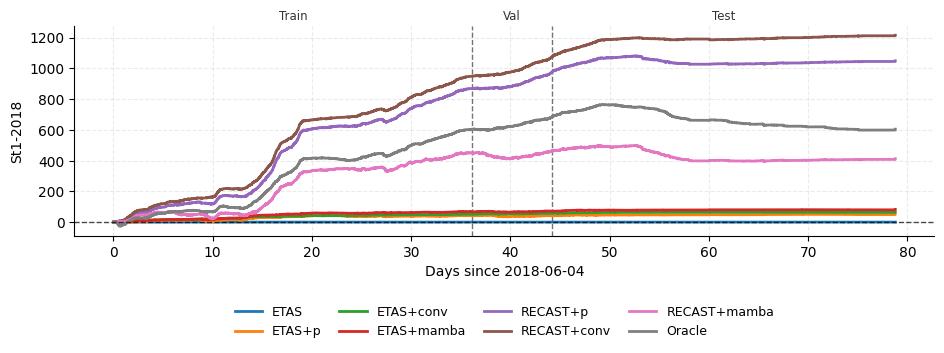

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.5))


def _meta_boundary_days(meta, start_ts, freq, scale, key_t, key_ts):
    if not hasattr(meta, 'get'):
        return None

    value = meta.get(key_t)
    if value is None:
        ts_value = meta.get(key_ts)
        if ts_value is not None and start_ts is not None and freq is not None:
            try:
                value = float((pd.Timestamp(ts_value) - pd.Timestamp(start_ts)) / pd.Timedelta(freq))
            except Exception:
                value = None

    if value is None:
        return None

    try:
        return float(value) * float(scale)
    except Exception:
        return None


def _draw_split_boundaries_paper(ax, x_min, x_max, val_x=None, test_x=None):
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_max <= x_min:
        return

    label_map = {
        'Train': 'Train',
        'Validation': 'Val',
        'Test': 'Test',
    }

    boundaries = []
    if val_x is not None and x_min < val_x < x_max:
        boundaries.append(('Validation', float(val_x)))
    if test_x is not None and x_min < test_x < x_max:
        boundaries.append(('Test', float(test_x)))
    boundaries = sorted(boundaries, key=lambda item: item[1])

    if len(boundaries) == 2:
        val_boundary = boundaries[0][1]
        test_boundary = boundaries[1][1]
        spans = [
            ('Train', x_min, val_boundary),
            ('Validation', val_boundary, test_boundary),
            ('Test', test_boundary, x_max),
        ]
    elif len(boundaries) == 1 and boundaries[0][0] == 'Test':
        test_boundary = boundaries[0][1]
        spans = [
            ('Train', x_min, test_boundary),
            ('Test', test_boundary, x_max),
        ]
    elif len(boundaries) == 1 and boundaries[0][0] == 'Validation':
        val_boundary = boundaries[0][1]
        spans = [
            ('Train', x_min, val_boundary),
            ('Validation', val_boundary, x_max),
        ]
    else:
        spans = []

    for split_name, left, right in spans:
        if right <= left:
            continue
        ax.text(
            0.5 * (left + right),
            1.015,
            label_map.get(split_name, split_name),
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='bottom',
            fontsize=8.5,
            color='#333333',
            clip_on=False,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.5),
            zorder=4,
        )

    for _, x in boundaries:
        ax.axvline(x, color='black', linestyle='--', linewidth=1.0, alpha=0.55, zorder=2)


x_min = min(float(np.min(res['curve']['time_plot_days'])) for res in model_results)
x_max = max(float(np.max(res['curve']['time_plot_days'])) for res in model_results)
val_boundary_days = _meta_boundary_days(
    catalog_meta,
    start_ts,
    freq,
    TIME_TO_DAYS_SCALE,
    key_t='val_start_t',
    key_ts='val_start_ts',
)
test_boundary_days = _meta_boundary_days(
    catalog_meta,
    start_ts,
    freq,
    TIME_TO_DAYS_SCALE,
    key_t='test_start_t',
    key_ts='test_start_ts',
)

_draw_split_boundaries_paper(ax, x_min, x_max, val_x=val_boundary_days, test_x=test_boundary_days)

for res in model_results:
    t = res['curve']['time_plot_days']
    y = res['curve'][PLOT_CURVE_KEY]
    ax.step(t, y, where='post', linewidth=2.0, label=res['label'])

if PLOT_DELTA_TO_BASELINE:
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)

ax.set_xlabel(TIME_XLABEL)
ax.set_ylabel(PLOT_CURVE_YLABEL)
# ax.set_title(PLOT_TITLE)
ax.grid(alpha=0.25, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
legend_cols = min(4, max(1, len(model_results)))
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=legend_cols,
    fontsize=9,
    frameon=False,
    columnspacing=1.4,
    handlelength=2.2,
)
fig.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.32)
plt.show()

## 7. Export Artifacts

This cell writes the plot and tabular outputs to disk, including per-time-step curves and a model-level summary CSV for downstream analysis.

In [7]:
import csv

# Export multi-model comparison outputs.
fig_path = FIG_EXPORT_DIR / f'cum_log_likelihood_compare_{base_args.dataset}_{SPLIT}_{SEQ_INDEX}.pdf'
curve_csv_path = METRIC_EXPORT_DIR / f'cum_log_likelihood_compare_{base_args.dataset}_{SPLIT}_{SEQ_INDEX}_curves.csv'
summary_csv_path = METRIC_EXPORT_DIR / f'cum_log_likelihood_compare_{base_args.dataset}_{SPLIT}_{SEQ_INDEX}_summary.csv'


def _meta_boundary_days(meta, start_ts, freq, scale, key_t, key_ts):
    if not hasattr(meta, 'get'):
        return None

    value = meta.get(key_t)
    if value is None:
        ts_value = meta.get(key_ts)
        if ts_value is not None and start_ts is not None and freq is not None:
            try:
                value = float((pd.Timestamp(ts_value) - pd.Timestamp(start_ts)) / pd.Timedelta(freq))
            except Exception:
                value = None

    if value is None:
        return None

    try:
        return float(value) * float(scale)
    except Exception:
        return None


def _draw_split_boundaries_paper(ax, x_min, x_max, val_x=None, test_x=None):
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_max <= x_min:
        return

    label_map = {
        'Train': 'Train',
        'Validation': 'Val',
        'Test': 'Test',
    }

    boundaries = []
    if val_x is not None and x_min < val_x < x_max:
        boundaries.append(('Validation', float(val_x)))
    if test_x is not None and x_min < test_x < x_max:
        boundaries.append(('Test', float(test_x)))
    boundaries = sorted(boundaries, key=lambda item: item[1])

    if len(boundaries) == 2:
        val_boundary = boundaries[0][1]
        test_boundary = boundaries[1][1]
        spans = [
            ('Train', x_min, val_boundary),
            ('Validation', val_boundary, test_boundary),
            ('Test', test_boundary, x_max),
        ]
    elif len(boundaries) == 1 and boundaries[0][0] == 'Test':
        test_boundary = boundaries[0][1]
        spans = [
            ('Train', x_min, test_boundary),
            ('Test', test_boundary, x_max),
        ]
    elif len(boundaries) == 1 and boundaries[0][0] == 'Validation':
        val_boundary = boundaries[0][1]
        spans = [
            ('Train', x_min, val_boundary),
            ('Validation', val_boundary, x_max),
        ]
    else:
        spans = []

    for split_name, left, right in spans:
        if right <= left:
            continue
        ax.text(
            0.5 * (left + right),
            1.015,
            label_map.get(split_name, split_name),
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='bottom',
            fontsize=8.5,
            color='#333333',
            clip_on=False,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.5),
            zorder=4,
        )

    for _, x in boundaries:
        ax.axvline(x, color='black', linestyle='--', linewidth=1.0, alpha=0.55, zorder=2)


val_boundary_days = _meta_boundary_days(
    catalog_meta,
    start_ts,
    freq,
    TIME_TO_DAYS_SCALE,
    key_t='val_start_t',
    key_ts='val_start_ts',
)
test_boundary_days = _meta_boundary_days(
    catalog_meta,
    start_ts,
    freq,
    TIME_TO_DAYS_SCALE,
    key_t='test_start_t',
    key_ts='test_start_ts',
)

# 1) Save comparison plot
fig, ax = plt.subplots(figsize=(10.8, 3.3))
x_min = min(float(np.min(res['curve']['time_plot_days'])) for res in model_results)
x_max = max(float(np.max(res['curve']['time_plot_days'])) for res in model_results)
_draw_split_boundaries_paper(ax, x_min, x_max, val_x=val_boundary_days, test_x=test_boundary_days)

for res in model_results:
    t_days = res['curve']['time_plot_days']
    y = res['curve'][PLOT_CURVE_KEY]
    ax.step(t_days, y, where='post', linewidth=2.0, label=res['label'])
if PLOT_DELTA_TO_BASELINE:
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
ax.set_xlabel(TIME_XLABEL, fontsize=11)
ax.set_ylabel(PLOT_CURVE_YLABEL, fontsize=11)
ax.set_title(PLOT_TITLE, fontsize=12, pad=20)
ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.35)
ax.tick_params(axis='both', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
legend_cols = min(4, max(1, len(model_results)))
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.30),
    ncol=legend_cols,
    fontsize=9,
    frameon=False,
    columnspacing=1.4,
    handlelength=2.2,
)
fig.subplots_adjust(left=0.12, right=0.98, top=0.80, bottom=0.34)
fig.savefig(fig_path, dpi=300)
plt.close(fig)

# 2) Save long-format curve data (includes plotted value and optional delta).
with open(curve_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'label', 'model_name', 'dataset', 'time_days', 'time_raw',
        'cum_log_likelihood_on_plot', 'cum_nll_on_plot',
        'cum_log_likelihood_delta', 'cum_log_likelihood_delta_segment_reset',
        'segment_reset_offset', 'segment_start_time_raw', 'segment_start_time_days',
        'plot_value', 'plot_key'
    ])
    for res in model_results:
        label = res['label']
        model_name = res['model_name']
        dataset = res['dataset']
        curve = res['curve']

        t_plot_raw = curve['time_plot']
        t_plot_days = curve['time_plot_days']
        ll_on_plot = curve['cum_log_likelihood_on_plot']
        nll_on_plot = curve['cum_nll_on_plot']
        delta_curve = curve.get(CIG_DELTA_CURVE_KEY, np.full_like(ll_on_plot, np.nan))
        reset_curve = curve.get(CIG_SEGMENT_RESET_CURVE_KEY, np.full_like(ll_on_plot, np.nan))
        reset_offset = curve.get(CIG_SEGMENT_RESET_OFFSET_KEY, np.full_like(ll_on_plot, np.nan))
        segment_start_raw = curve.get(CIG_SEGMENT_START_TIME_KEY, np.full_like(ll_on_plot, np.nan))
        segment_start_days = np.asarray(segment_start_raw, dtype=float) * TIME_TO_DAYS_SCALE
        plot_values = curve[PLOT_CURVE_KEY]

        for t_days, t_raw, ll, nll, dlt, reset_dlt, offset, seg_raw, seg_days, p in zip(
            t_plot_days,
            t_plot_raw,
            ll_on_plot,
            nll_on_plot,
            delta_curve,
            reset_curve,
            reset_offset,
            segment_start_raw,
            segment_start_days,
            plot_values,
        ):
            writer.writerow([
                label,
                model_name,
                dataset,
                float(t_days),
                float(t_raw),
                float(ll),
                float(nll),
                float(dlt) if np.isfinite(dlt) else '',
                float(reset_dlt) if np.isfinite(reset_dlt) else '',
                float(offset) if np.isfinite(offset) else '',
                float(seg_raw) if np.isfinite(seg_raw) else '',
                float(seg_days) if np.isfinite(seg_days) else '',
                float(p),
                PLOT_CURVE_KEY,
            ])

# 3) Save summary data
with open(summary_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'label', 'model_name', 'dataset', 'checkpoint_path', 'num_seeds',
        'num_events_in_nll', 'selected_component', 'final_log_likelihood_selected',
        'computed_selected_nll', 'model_selected_nll',
        'model_time_nll', 'model_total_nll', 'abs_diff',
        'final_delta_vs_baseline', 'final_split_reset_delta',
        'final_plot_value', 'plot_key', 'split_reset_enabled'
    ])
    for res in model_results:
        final_delta = (
            float(res['curve'][CIG_DELTA_CURVE_KEY][-1])
            if CIG_DELTA_CURVE_KEY in res['curve']
            else ''
        )
        final_split_reset_delta = (
            float(res['curve'][CIG_SEGMENT_RESET_CURVE_KEY][-1])
            if CIG_SEGMENT_RESET_CURVE_KEY in res['curve']
            else ''
        )
        final_plot_value = (
            float(res['curve'][PLOT_CURVE_KEY][-1])
            if PLOT_CURVE_KEY in res['curve']
            else ''
        )
        writer.writerow([
            res['label'],
            res['model_name'],
            res['dataset'],
            res['checkpoint_path'],
            int(res['meta'].get('num_seeds', 1)),
            int(res['meta']['num_events_in_nll']),
            NLL_COMPONENT_LABEL,
            float(res['final_log_likelihood_selected']),
            float(res['computed_nll_selected']),
            float(res['nll_ref_selected']),
            float(res['nll_time_ref']),
            float(res['nll_total_ref']),
            float(res['abs_diff']),
            final_delta,
            final_split_reset_delta,
            final_plot_value,
            PLOT_CURVE_KEY,
            PLOT_CURVE_KEY == CIG_SEGMENT_RESET_CURVE_KEY,
        ])

print(f'Saved comparison plot : {fig_path}')
print(f'Saved curves CSV      : {curve_csv_path}')
print(f'Saved summary CSV     : {summary_csv_path}')

Saved comparison plot : /root/autodl-tmp/em_eqf/notebooks/figs/cumulative_likelihood_over_time/cum_log_likelihood_compare_St1-2018_test_0.pdf
Saved curves CSV      : /root/autodl-tmp/em_eqf/notebooks/metrics/cumulative_likelihood_over_time/cum_log_likelihood_compare_St1-2018_test_0_curves.csv
Saved summary CSV     : /root/autodl-tmp/em_eqf/notebooks/metrics/cumulative_likelihood_over_time/cum_log_likelihood_compare_St1-2018_test_0_summary.csv
